In [7]:
# =============================
# INSTALAÇÃO DAS BIBLIOTECAS
# =============================
!pip install networkx matplotlib python-louvain python-igraph leidenalg scipy pandas

# =============================
# IMPORTAÇÕES
# =============================
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
from community import community_louvain
from networkx.algorithms import community as nx_comm
import igraph as ig
import leidenalg

# =============================
# 1. CARREGAMENTO DA REDE FACEBOOK
# =============================
# O dataset 'Facebook_combined.txt' deve estar na pasta 'data/'
G_FB = nx.read_edgelist("data/facebook_combined.txt", create_using=nx.Graph(), nodetype=int)

print("=== Estatísticas da Rede do Facebook ===")
print("Número de nós:", G_FB.number_of_nodes())
print("Número de arestas:", G_FB.number_of_edges())
print("Grau médio:", round(sum(dict(G_FB.degree()).values()) / G_FB.number_of_nodes(), 2))

# Layout fixo para garantir consistência visual entre algoritmos
np.random.seed(42)
spring_pos = nx.spring_layout(G_FB, seed=42)

# =============================
# FUNÇÕES AUXILIARES
# =============================

def plot_communities(G, pos, partition, title, filename=None):
    """Gera visualização colorida por comunidade."""
    unique_comms = set(partition.values())
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_comms)))
    node_colors = [colors[partition[node]] for node in G.nodes()]

    plt.figure(figsize=(12, 10))
    nx.draw_networkx(G, pos=pos, node_color=node_colors, node_size=10, with_labels=False)
    plt.title(title)
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

def calculate_metrics(G, communities, algorithm_name, execution_time):
    """Calcula métricas de desempenho das comunidades."""
    if isinstance(communities, dict):  # Ex: Louvain
        communities = [set([k for k, v in communities.items() if v == c])
                      for c in set(communities.values())]
    
    modularity = nx_comm.modularity(G, communities)
    sizes = [len(c) for c in communities]
    
    return {
        "Algoritmo": algorithm_name,
        "Tempo (s)": round(execution_time, 2),
        "Modularidade": round(modularity, 4),
        "Nº Comunidades": len(sizes),
        "Tamanho Médio": round(np.mean(sizes), 2),
        "Desvio Padrão": round(np.std(sizes), 2)
    }


=== Estatísticas da Rede do Facebook ===
Número de nós: 4039
Número de arestas: 88234
Grau médio: 43.69



=== Executando Louvain ===
{'Algoritmo': 'Louvain', 'Tempo (s)': 1.44, 'Modularidade': 0.8349, 'Nº Comunidades': 15, 'Tamanho Médio': 269.27, 'Desvio Padrão': 177.31}


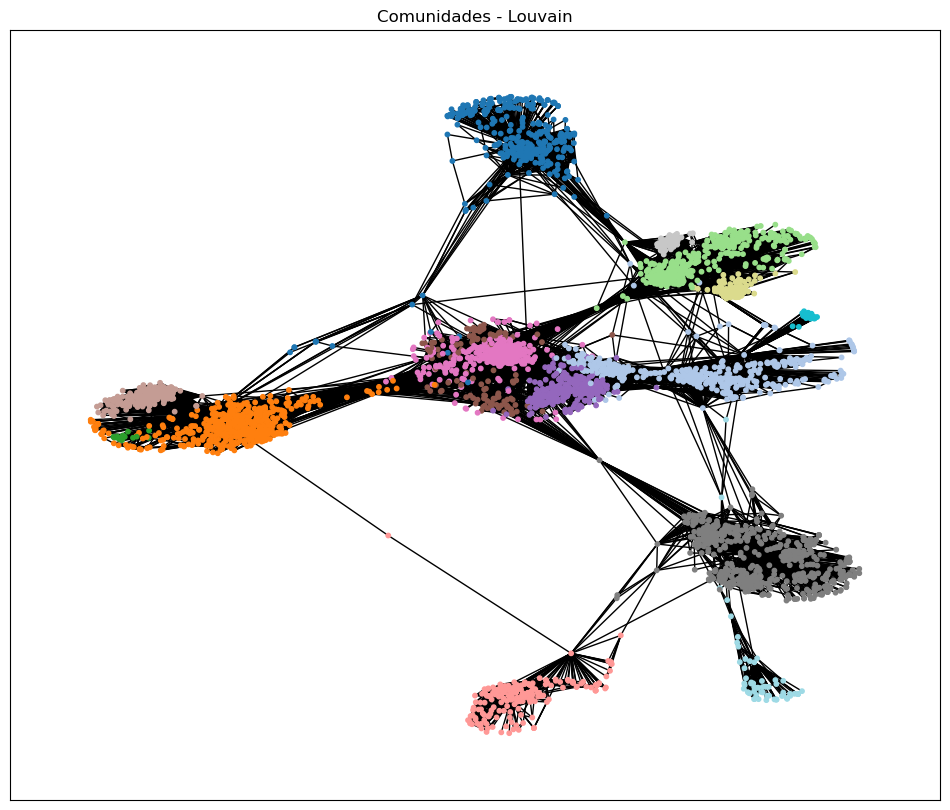

In [8]:
# =============================
# 2. LOOUVAIN
# =============================
print("\n=== Executando Louvain ===")
start = time.time()
partition_louvain = community_louvain.best_partition(G_FB)
louvain_time = time.time() - start
metrics_louvain = calculate_metrics(G_FB, partition_louvain, "Louvain", louvain_time)
print(metrics_louvain)
plot_communities(G_FB, spring_pos, partition_louvain, "Comunidades - Louvain", "Facebook_louvain.png")


=== Executando Label Propagation ===
{'Algoritmo': 'Label Propagation', 'Tempo (s)': 0.28, 'Modularidade': 0.7368, 'Nº Comunidades': 44, 'Tamanho Médio': 91.8, 'Desvio Padrão': 210.85}


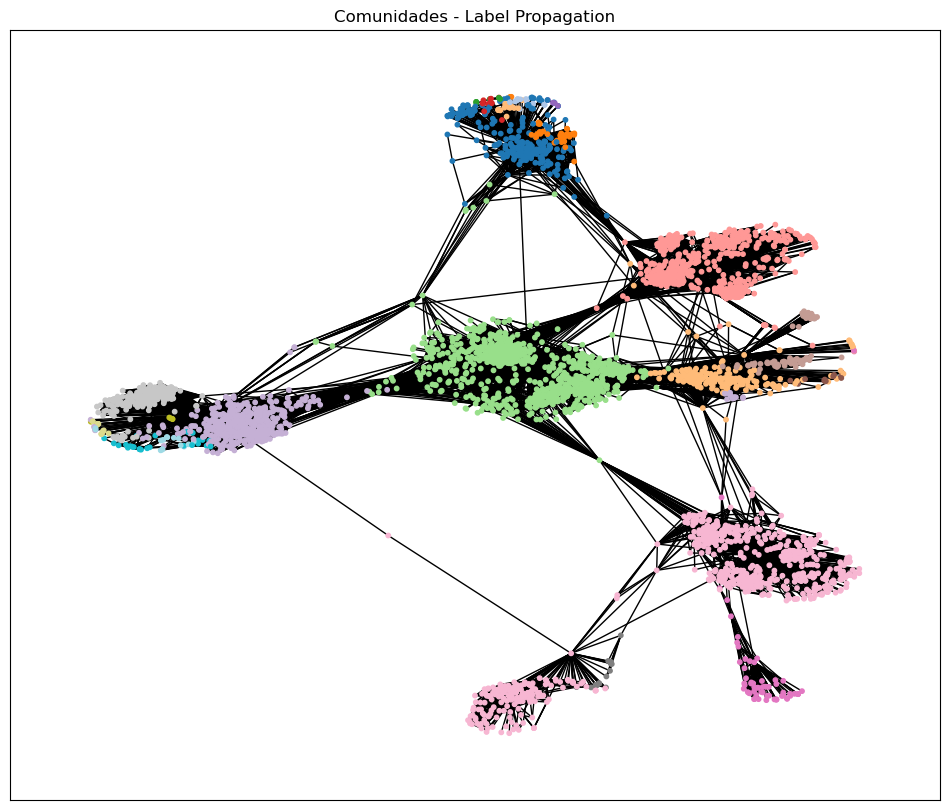

In [9]:
# =============================
# 3. LABEL PROPAGATION
# =============================
print("\n=== Executando Label Propagation ===")
start = time.time()
communities_lpa = list(nx_comm.label_propagation_communities(G_FB))
lpa_time = time.time() - start
partition_lpa = {node: i for i, comm in enumerate(communities_lpa) for node in comm}
metrics_lpa = calculate_metrics(G_FB, communities_lpa, "Label Propagation", lpa_time)
print(metrics_lpa)
plot_communities(G_FB, spring_pos, partition_lpa, "Comunidades - Label Propagation", "Facebook_lpa.png")


=== Executando Leiden ===
{'Algoritmo': 'Leiden', 'Tempo (s)': 0.04, 'Modularidade': 0.8356, 'Nº Comunidades': 16, 'Tamanho Médio': 252.44, 'Desvio Padrão': 190.02}


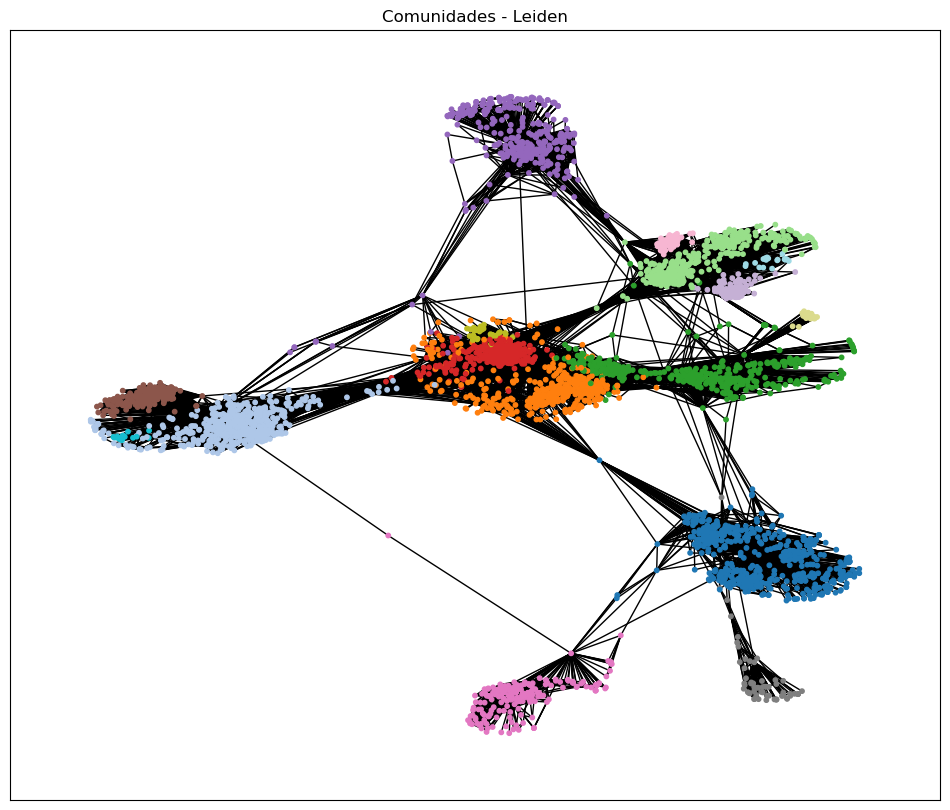

In [12]:
# =============================
# 4. LEIDEN
# =============================
print("\n=== Executando Leiden ===")
edges = list(G_FB.edges())
G_ig = ig.Graph.TupleList(edges, directed=False)
start = time.time()
partition_leiden = leidenalg.find_partition(G_ig, leidenalg.ModularityVertexPartition)
leiden_time = time.time() - start

# Conversão para dicionário
partition_leiden_nx = {int(G_ig.vs[node]["name"]): i for i, comm in enumerate(partition_leiden) for node in comm}
communities_leiden = [set([int(G_ig.vs[node]["name"]) for node in comm]) for comm in partition_leiden]
metrics_leiden = calculate_metrics(G_FB, communities_leiden, "Leiden", leiden_time)
print(metrics_leiden)
plot_communities(G_FB, spring_pos, partition_leiden_nx, "Comunidades - Leiden", "Facebook_leiden.png")



=== Comparação Final ===
           Algoritmo  Tempo (s)  Modularidade  Nº Comunidades  Tamanho Médio  \
0            Louvain       1.44        0.8349              15         269.27   
1  Label Propagation       0.28        0.7368              44          91.80   
2             Leiden       0.04        0.8356              16         252.44   

   Desvio Padrão  
0         177.31  
1         210.85  
2         190.02  


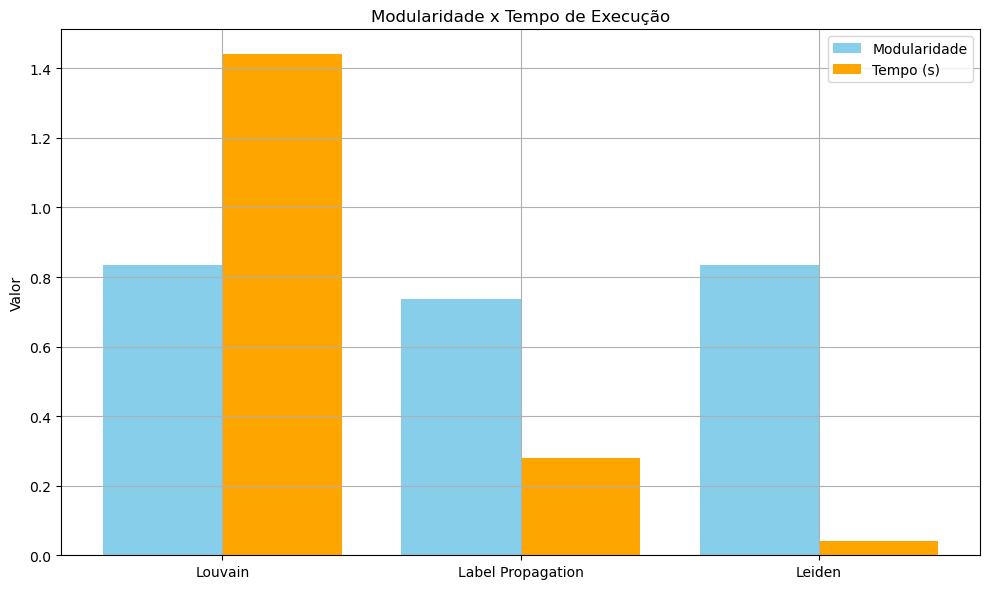

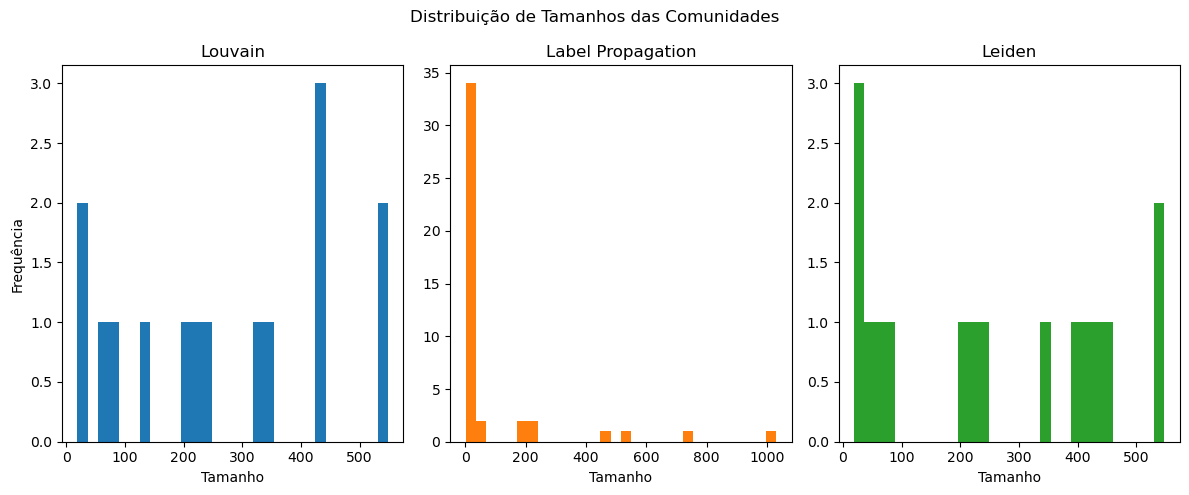

In [13]:
# =============================
# 5. COMPARAÇÃO FINAL
# =============================
print("\n=== Comparação Final ===")
results = pd.DataFrame([metrics_louvain, metrics_lpa, metrics_leiden])
print(results)

# Gráfico comparativo: Modularidade x Tempo
plt.figure(figsize=(10, 6))
x = range(len(results))
plt.bar(x, results["Modularidade"], width=0.4, label="Modularidade", color="skyblue")
plt.bar([i + 0.4 for i in x], results["Tempo (s)"], width=0.4, label="Tempo (s)", color="orange")
plt.xticks([i + 0.2 for i in x], results["Algoritmo"])
plt.ylabel("Valor")
plt.title("Modularidade x Tempo de Execução")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Facebook_comparacao_modularidade_tempo.png", dpi=300)
plt.show()

# Histograma de tamanhos das comunidades
plt.figure(figsize=(12, 5))
for i, (nome, part) in enumerate([
    ("Louvain", partition_louvain),
    ("Label Propagation", partition_lpa),
    ("Leiden", partition_leiden_nx)
]):
    sizes = [list(part.values()).count(c) for c in set(part.values())]
    plt.subplot(1, 3, i+1)
    plt.hist(sizes, bins=30, color=plt.cm.tab10(i))
    plt.title(nome)
    plt.xlabel("Tamanho")
    if i == 0:
        plt.ylabel("Frequência")
plt.suptitle("Distribuição de Tamanhos das Comunidades")
plt.tight_layout()
plt.savefig("Facebook_distribuicao_comunidades.png", dpi=300)
plt.show()


1. Modularidade
Definição: A modularidade mede a qualidade da divisão da rede em comunidades. Quanto maior, melhor a separação entre grupos.

Análise: O Leiden apresentou a maior modularidade (0.8356), seguido de perto pelo Louvain (0.8349), indicando que ambos identificaram comunidades bem definidas. O Label Propagation ficou significativamente abaixo (0.7368), o que mostra uma menor qualidade na separação das comunidades.

Explicacao: Modularidade alta indica que os nós dentro de cada comunidade têm muitas conexões entre si e poucas com outros grupos.

2. Tempo de Execução
O Leiden foi o mais rápido (0.04s), mesmo sendo mais recente e robusto.

O Louvain, apesar de eficiente, foi 36 vezes mais lento que o Leiden.

O Label Propagation também foi rápido (0.28s), mas com modularidade mais fraca.

Em cenários de grande escala, algoritmos como Leiden são preferíveis, pois oferecem qualidade e eficiência computacional.

3. Número de Comunidades
O Label Propagation detectou 44 comunidades, muito mais do que Louvain (15) e Leiden (16).

Porém, isso não significa melhor desempenho. Ele fragmentou demais a rede, perdendo coesão e qualidade (ver modularidade).

Obs: Que um número excessivo de comunidades pode indicar supersegmentação, especialmente se acompanhado de baixa modularidade.

4. Tamanho Médio das Comunidades e Desvio Padrão
O Label Propagation teve a menor média de tamanho e o maior desvio padrão, mostrando muita variação e desigualdade nos tamanhos das comunidades.

Louvain e Leiden tiveram tamanhos médios próximos (≈250) e menor desvio, o que mostra distribuição mais balanceada.

Explicacao: Muito desvio indica desequilíbrio entre as comunidades, o que pode ser indesejável em certas aplicações como distribuição de carga ou análise social.

Conclusao

“Com base nas métricas analisadas, o algoritmo Leiden apresentou o melhor desempenho geral. Ele alcançou a maior modularidade, com ótima eficiência computacional e uma distribuição equilibrada de comunidades.

O Louvain também teve excelente qualidade na detecção, mas levou mais tempo.

Já o Label Propagation, embora rápido, teve desempenho inferior na qualidade das comunidades, identificando muitas comunidades pequenas e mal separadas.

Portanto, para redes como a do Facebook, que são densas e com estrutura modular complexa, o Leiden se mostra a melhor escolha, seguido de perto pelo Louvain.”